**Overfitting, Underfitting and Best Fit**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


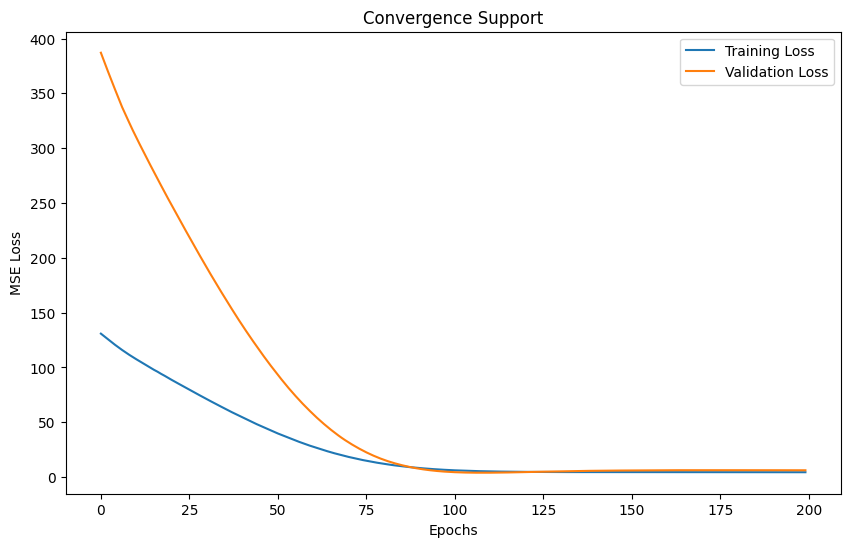

In [ ]:
import numpy as np; import matplotlib.pyplot as plt
import tensorflow as tf; from tensorflow import keras
from tensorflow.keras import layers

# Generate synthetic data
np.random.seed(0)
X = np.linspace(0, 10, 200)
y = 2 * X + 3 + np.random.normal(0, 2, size=200)

# Train-test split
X_train, X_test = X[:150], X[150:]
y_train, y_test = y[:150], y[150:]

# Originail
# Define a simple neural network
# model = keras.Sequential([
# layers.Dense(10, activation='relu', input_shape=[1]),
# layers.Dense(1)
# ])

model = keras.Sequential([
layers.Dense(15, activation='relu', input_shape=[1]),
layers.Dense(1)
])

# Compile and train
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=200, verbose=0,
validation_data=(X_test, y_test))

# Plot training vs validation loss
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Convergence Support")
plt.legend()
plt.show()

**Early Stopping**:

if epoch =10

如果 validation loss 連續 10 個 epoch 都沒有改善，就停止。



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Stopped at epoch: 88


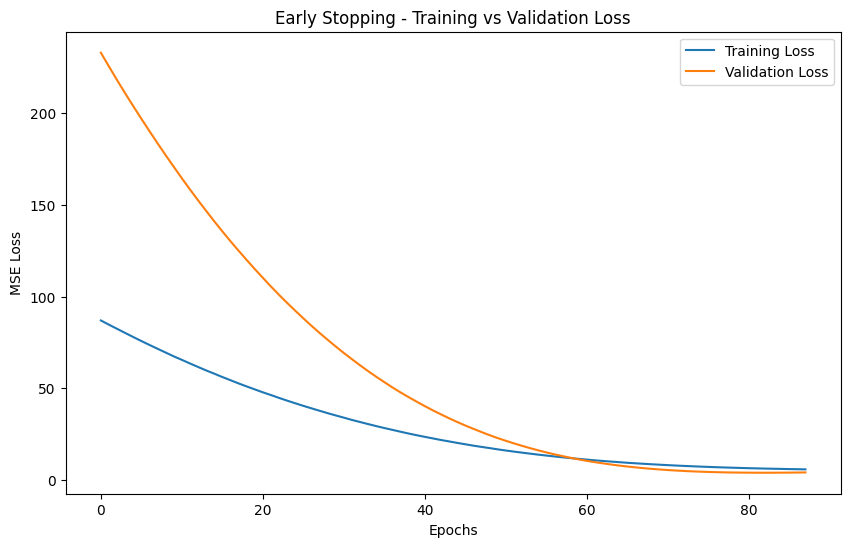

In [5]:
import numpy as np; import matplotlib.pyplot as plt
import tensorflow as tf; from tensorflow import keras
from tensorflow.keras import layers

# Generate synthetic data
np.random.seed(0); X = np.linspace(0, 10, 200)
y = 2 * X + 3 + np.random.normal(0, 2, size=200)

# Train-test split
X_train, X_test = X[:150], X[150:]; y_train, y_test = y[:150], y[150:]

# Define simple neural network
model = keras.Sequential([
layers.Dense(10, activation='relu', input_shape=[1]),
layers.Dense(1)])

model.compile(optimizer='adam', loss='mse')

# Early stopping callback
early_stop = keras.callbacks.EarlyStopping(
monitor='val_loss',
# patience=20, # stop if no improvement for 20 epochs
patience = 5,
restore_best_weights=True)

# Train with early stopping
history = model.fit(X_train, y_train, epochs=500, verbose=0,
validation_data=(X_test, y_test),
callbacks=[early_stop])

print("Stopped at epoch:", len(history.history['loss']))

# Visualization: Training vs Validation Loss
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Early Stopping - Training vs Validation Loss")
plt.legend()
plt.show()

**Model with Dropout**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


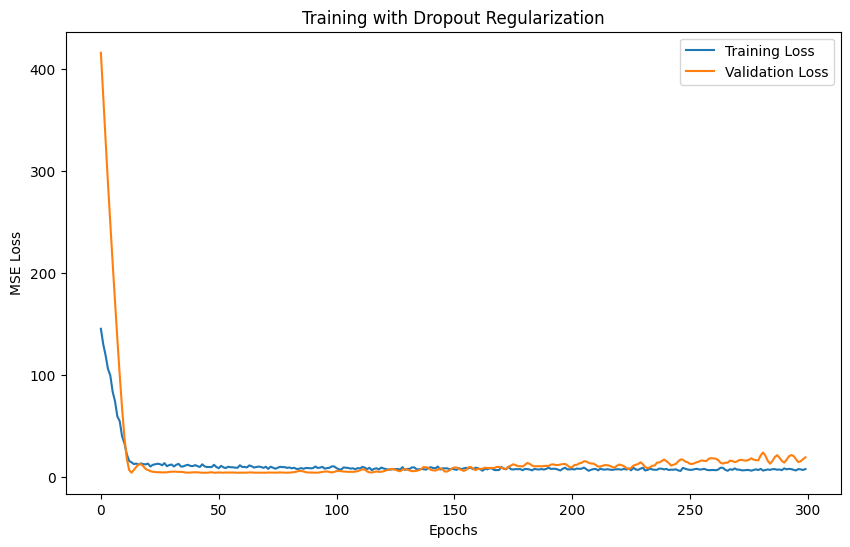

In [7]:
import numpy as np; import matplotlib.pyplot as plt
import tensorflow as tf; from tensorflow import keras
from tensorflow.keras import layers

# Synthetic dataset
np.random.seed(0); X = np.linspace(0, 10, 200)
y = 2 * X + 3 + np.random.normal(0, 2, size=200)

X_train, X_test = X[:150], X[150:]
y_train, y_test = y[:150], y[150:]

# Neural network with dropout
model = keras.Sequential([
layers.Dense(64, activation='relu', input_shape=[1]),
layers.Dropout(0.5), # randomly drop 50% of neurons
layers.Dense(64, activation='relu'),
# layers.Dropout(0.5),
layers.Dropout(0.2),
layers.Dense(1)])

model.compile(optimizer='adam', loss='mse')

# Train with validation
history = model.fit(X_train, y_train, epochs=300, verbose=0,
validation_data=(X_test, y_test))

# Visualization
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training with Dropout Regularization")
plt.legend()
plt.show()

**Regularization - L2**

In [9]:
import numpy as np; import matplotlib.pyplot as plt
import tensorflow as tf; from tensorflow import keras
from tensorflow.keras import layers, regularizers

# Generate data
np.random.seed(0); X = np.linspace(0, 10, 200)
y = 2 * X + 3 + np.random.normal(0, 2, size=200)

X_train, X_test = X[:150], X[150:]; y_train, y_test = y[:150], y[150:]

# Define model with L2 regularization
model = keras.Sequential([
layers.Dense(64, activation='relu',
kernel_regularizer=regularizers.l2(0.01),
input_shape=[1]),
layers.Dense(64, activation='relu' ,
kernel_regularizer=regularizers.l2(0.01)
),
layers.Dense(1)])

model.compile(optimizer='adam', loss='mse')

# Train
history = model.fit(X_train, y_train, epochs=200,
validation_data=(X_test, y_test))

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 142.4069 - val_loss: 403.1400
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 130.4180 - val_loss: 367.1569
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 120.3724 - val_loss: 335.2780
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 110.9178 - val_loss: 303.4444
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 102.1408 - val_loss: 271.2211
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 92.4513 - val_loss: 239.1484
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 82.8263 - val_loss: 205.3382
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 72.4620 - val_loss: 171.3873
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 62.0657 - val_loss: 136.1300
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 50.7884 - val_loss: 100.7407
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 39.5593 - val_loss: 67.5664
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━

**Batch Normalization**

In [ ]:
import numpy as np;
import matplotlib.pyplot as plt
import tensorflow as tf;
from tensorflow import keras
from tensorflow.keras import layers

# Synthetic dataset
np.random.seed(0); X = np.linspace(0, 10, 200)
y = 2 * X + 3 + np.random.normal(0, 2, size=200)

X_train, X_test = X[:150], X[150:]; y_train, y_test = y[:150], y[150:]

# Model with batch normalization
model = keras.Sequential([
layers.Dense(64, activation='relu', input_shape=[1]),
layers.BatchNormalization(), # normalize activations
layers.Dense(64, activation='relu'),
layers.BatchNormalization(),
layers.Dense(1)])

model.compile(optimizer='adam', loss='mse')

# Train
history = model.fit(X_train, y_train, epochs=200,
validation_data=(X_test, y_test))

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 141.2606 - val_loss: 443.8830
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 124.0498 - val_loss: 376.7003
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 118.1919 - val_loss: 333.9551
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 117.0841 - val_loss: 315.6186
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 115.0740 - val_loss: 308.6805
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 113.1347 - val_loss: 304.1695
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 114.0897 - val_loss: 298.3711
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 112.0337 - val_loss: 292.5538
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 110.3916 - val_loss: 288.7829
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 108.7695 - val_loss: 284.6251
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 106.5994 - val_loss: 278.0052
Epoch 12/200
5/5 ━━━━━━━━━━━━━

**Training with SGD and Adam**

In [ ]:
import numpy as np;
import tensorflow as tf
from tensorflow import keras;
from tensorflow.keras import layers

# Synthetic dataset
X = np.linspace(0, 10, 200)
y = 2 * X + 3 + np.random.normal(0, 2, size=200)

X_train, X_test = X[:150], X[150:]
y_train, y_test = y[:150], y[150:]

# Model definition
def build_model():
    return keras.Sequential([
        layers.Dense(10, activation='relu', input_shape=[1]),
        layers.Dense(1)
    ])

# Train with SGD
model_sgd = build_model()
model_sgd.compile(optimizer='sgd', loss='mse')
history_sgd = model_sgd.fit(X_train, y_train, epochs=100,
                            validation_data=(X_test, y_test))

# Train with Adam
model_adam = build_model()
model_adam.compile(optimizer='adam', loss='mse')
history_adam = model_adam.fit(X_train, y_train, epochs=100,
                              validation_data=(X_test, y_test))

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 30.2508 - val_loss: 20.0641
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 13.0812 - val_loss: 98.6045
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 19.4062 - val_loss: 22.2592
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 6.3116 - val_loss: 11.8750
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 5.8200 - val_loss: 15.2973
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 5.5288 - val_loss: 8.6060
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 5.1944 - val_loss: 24.5449
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 9.7258 - val_loss: 19.4892
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 5.7866 - val_loss: 6.3926
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 5.8165 - val_loss: 7.3559
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 5.1430 - val_loss: 9.0979
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 5.1760 - val_loss